In [1]:
%load_ext autoreload
%autoreload 2

# Static autoencoder performance as a function of background activity

In [2]:
import torch
from wassa_functions import performance_as_a_function_of_dataset_parameters
from dataset_generation import get_dataset_parameters
from wassa_training import get_training_parameters
from wassa_plots import plot_results_std
import matplotlib.pyplot as plt
import numpy as np

In [3]:
date = '2025-10-15'
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [4]:
device = 'cuda:0'

In [5]:
dataset_parameters = {
    'seed' : 666,
    
    'N_pre' : 260, # number of neurons
    'N_timesteps' : 250, # number of timesteps for the raster plot (in ms)
    'N_samples' : 30, # total number of samples in the dataset
    'N_sms' : 1, # number of structured spiking motifs

    'temporal_jitter' : 0, # temporal jitter for the spike generation in motifs
    'dropout_proba' : 0, # probabilistic participations of the different neurons to the spiking motif
    'additive_noise' : 0, # percentage of background noise/spontaneous activity
    'min_warping_coef' : 1, # coefficient for time warping
}
dataset_parameters.update({'N_involved':dataset_parameters['N_pre']*torch.ones(dataset_parameters['N_sms'])}) # number of neurons involved in the spiking motif
dataset_parameters.update({'proba_sms' : torch.ones(dataset_parameters['N_sms'])/dataset_parameters['N_sms']}) # probability of apparition of the different spiking motif

In [6]:
training_parameters_emd = {
    'kernel_size' : (dataset_parameters['N_sms'], dataset_parameters['N_pre'], dataset_parameters['N_timesteps']),
    'loss_type' : 'emd',
    'activation' : 'emd like',
    'sigmoid' : False,
    'kernels_norm' : True,
    'N_learnsteps' : 2000,
    'learning_rate' : .1,
    'penalty_type' : [None],
    'lambda' : [0],
    'batch_size' : None,
    'do_bias' : False,
    'weight_init' : 'flat',
    'normalize_input' : True
}

In [7]:
training_parameters_mse = {
    'kernel_size' : (dataset_parameters['N_sms'], dataset_parameters['N_pre'], dataset_parameters['N_timesteps']),
    'loss_type' : 'mse',
    'activation' : 'conv',
    'sigmoid' : False,
    'kernels_norm' : 2,
    'N_learnsteps' : 2000,
    'learning_rate' : .05,
    'penalty_type' : [None],
    'lambda' : [0],
    'batch_size' : None,
    'do_bias' : False,
    'weight_init' : 'flat',
    'normalize_input' : True
}

In [8]:
dataset_variables = {
'additive_noise' : torch.linspace(0,.9,10).tolist(),
}

In [9]:
file_name = '../simulations/results_additive_last'+get_training_parameters(training_parameters_emd)+get_training_parameters(training_parameters_mse)
training_metrics = ['training loss', 'testing loss', 'explained variance']
synthetic_metrics = ['kernels similarity', 'mean timings similarity', 'mse', 'emd', 'emd mean timings', 'mean time diff']
n_iter = 100
kfold = 1
do_seqnmf = False
results, _ = performance_as_a_function_of_dataset_parameters(file_name, dataset_parameters, training_parameters_emd, training_parameters_mse, dataset_variables, training_metrics, synthetic_metrics, n_iter = n_iter, kfold=kfold, do_seqnmf = do_seqnmf, device=device)

0it [00:00, ?it/s]

zero values are set as 1e-05
zero values are set as 1e-05


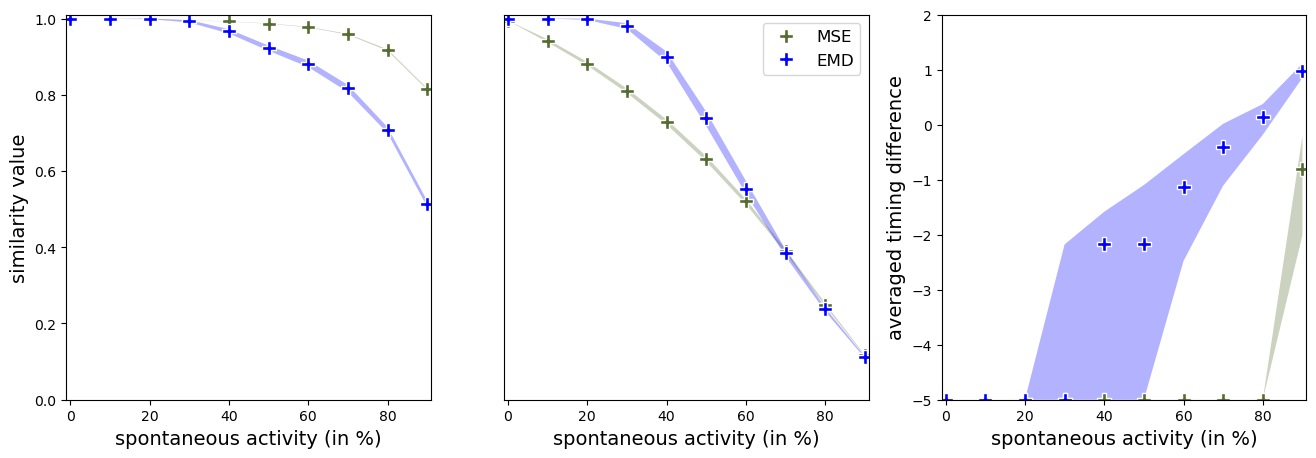

In [10]:
name_metrics = ['kernels similarity', 'mean timings similarity', 'mean time diff']
name_methods = ['MSE','EMD']
colors = ['darkolivegreen','blue','purple','orangered']
xlabel = 'spontaneous activity (in %)'
quantile = True
plot_all = False

fig, ax = plt.subplots(1,3, figsize=(16,5))
for i in range(len(name_metrics)):
    for m in range(len(name_methods)):
        ymin, ymax = 0, 1.01
        xmin, xmax = -1, 91
        do_legend, log_x, log_y = False, False, False
        if i==0:
            ylabel = 'similarity value'
        elif i==2:
            ylabel = 'averaged timing difference'
            ymin, ymax = -5, 2
            log_y = True
        else:
            ylabel = None
            do_legend = True
        ax[i] = plot_results_std(ax[i],results[:,m],[i*100 for i in dataset_variables['additive_noise']],training_metrics+synthetic_metrics,xlabel,name_metrics[i],name_methods[m],colors[m],ymax=ymax,ymin=ymin,xmax=xmax,xmin=xmin,ylabel=ylabel,do_legend=do_legend,log_x=log_x,log_y=log_y,quantile=quantile,plot_all_points=plot_all)

In [11]:
ax[2].set_yticklabels([0,'$10^{-4}$','$10^{-3}$','$10^{-2}$','$10^{-1}$','$10^{0}$','$10^{1}$','$10^{2}$']);

/tmp/ipykernel_1412573/2804495067.py:1: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[2].set_yticklabels([0,'$10^{-4}$','$10^{-3}$','$10^{-2}$','$10^{-1}$','$10^{0}$','$10^{1}$','$10^{2}$']);


In [12]:
fig.tight_layout()
fig.savefig('../figures/results_spontaneous_static.pdf', bbox_inches = 'tight')